# Sequential GMM Thresholding for Cell Cycle Staging

This notebook demonstrates the `SequentialGaussianMixtureModelThresholding` class from the `cc_mapping` package. This class enables **iterative refinement** of cell populations through sequential thresholding operations.

## What is Sequential Thresholding?

Sequential thresholding allows you to:
1. Start with a broad classification (e.g., Low vs High)
2. Refine specific subpopulations using additional features
3. Track the complete refinement history and metadata
4. Visualize results at each step

This is particularly useful for **cell cycle staging**, where you progressively refine populations using different markers.

## Use Case: Cell Cycle Staging

In this notebook, we'll perform a complete cell cycle staging workflow:
1. **Initial split**: Use pRB to separate G0 (quiescent) from cycling cells (G1/S/G2/M)
2. **First refinement**: Use p21 to separate M phase from G1/S/G2
3. **Second refinement**: Use DNA content to split G1/S/G2 into individual phases

## Table of Contents

1. [Setup and Data Loading](#setup)
2. [Step 1: Initial Thresholding (G0 vs G1/S/G2/M)](#step1)
3. [Step 2: First Refinement (Separate M phase)](#step2)
4. [Step 3: Second Refinement (G1, S, G2)](#step3)
5. [Visualizing the Evolution](#evolution)
6. [Metadata and Reproducibility](#metadata)
7. [Summary and Best Practices](#summary)

<a id="setup"></a>
## 1. Setup and Data Loading

First, import the required libraries and load the example dataset.

In [47]:
from pathlib import Path
from urllib.request import urlretrieve

import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import sys
sys.path.append("R:\Dante\git\cc_mapping\src")

from cc_mapping.thresholding import SequentialGaussianMixtureModelThresholding

### Download and Load Example Dataset

We'll use the same control manifold dataset from the basic thresholding notebook.

In [48]:
url = "https://zenodo.org/records/4525425/files/control_manifold_allfeatures.csv?download=1"

cwd = Path.cwd()
download_path = cwd / "data" / "control_manifold_allfeatures.csv"

if not download_path.parent.exists():
    download_path.parent.mkdir(parents=True)
    urlretrieve(url, download_path)

In [49]:
# Create results directory structure for saving figures
results_dir = cwd / "results"
sequential_results_dir = results_dir / "sequential"

# Create directories if they don't exist
results_dir.mkdir(exist_ok=True)
sequential_results_dir.mkdir(exist_ok=True)

print(f"Results directory created at: {results_dir}")
print(f"Sequential results directory: {sequential_results_dir}")

Results directory created at: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results
Sequential results directory: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\sequential


### Results Directory Setup

All plotting functions now support an optional `save_path` parameter to automatically save figures. The parent directory must exist before saving, so we create the directory structure here.

In [50]:
# Load and convert to AnnData
csv = pd.read_csv(download_path, index_col=0, low_memory=False)
csv.index = csv.index.astype(str)

adata = ad.AnnData(
    X=csv.values[:,:-10].astype(np.float32),
)
adata.var_names = csv.columns.values[:-10]

print(f"Dataset: {adata.n_obs} cells x {adata.n_vars} features")
print(f"\nFeatures we'll use:")
print(f"  - pRB (nuc median): Initial G0 vs cycling split")
print(f"  - pp21 (nuc median): Separate M phase")
print(f"  - Int_Intg_DNA_nuc: Split G1/S/G2")

Dataset: 6797 cells x 289 features

Features we'll use:
  - pRB (nuc median): Initial G0 vs cycling split
  - pp21 (nuc median): Separate M phase
  - Int_Intg_DNA_nuc: Split G1/S/G2


### Filter Out Cells with Missing Values

Before performing GMM thresholding, we need to remove cells with NaN values in the features we'll use. This is required because sklearn's GaussianMixture does not accept missing values.

In [51]:
# Define the features we'll use for sequential thresholding
features_to_use = ['pRB (nuc median)', 'pp21 (nuc median)', 'Int_Intg_DNA_nuc']

# Get feature indices
feature_indices = [list(adata.var_names).index(f) for f in features_to_use]

# Find cells with NaN values in any of these features
cells_with_nan = np.any(np.isnan(adata.X[:, feature_indices]), axis=1)

print(f"Cells with NaN values: {cells_with_nan.sum()} / {adata.n_obs}")

# Filter out cells with NaN values
if cells_with_nan.sum() > 0:
    adata = adata[~cells_with_nan, :].copy()
    print(f"After filtering: {adata.n_obs} cells remaining")
else:
    print("No cells with NaN values found!")

Cells with NaN values: 1 / 6797
After filtering: 6796 cells remaining


<a id="step1"></a>
## 2. Step 1: Initial Thresholding (G0 vs G1/S/G2/M)

We'll start by using **pRB (phosphorylated Retinoblastoma protein)** to separate quiescent G0 cells from actively cycling cells (G1/S/G2/M).

### Initialize Sequential Thresholding Object

In [52]:
# Initialize the sequential thresholding object
gmm_kwargs = {'init_params': 'k-means++', 'n_init': 10, 'max_iter': 1000, 'random_state': 42}

seq_gmm = SequentialGaussianMixtureModelThresholding(
    adata=adata,
    thresholding_events_key='sequential_gmm_thresholding',
    gmm_kwargs=gmm_kwargs
)

print("Sequential thresholding object initialized!")
print("Metadata will be stored in: adata.uns['sequential_gmm_thresholding']")

Sequential thresholding object initialized!
Metadata will be stored in: adata.uns['sequential_gmm_thresholding']


### Threshold Entire Dataset with pRB

Use `threshold_entire_dataset()` to perform the initial split.

### Exploratory Visualization (Optional)

Before running the thresholding operation, we can explore the data distribution to help us decide on parameters like the number of components or manual threshold values.

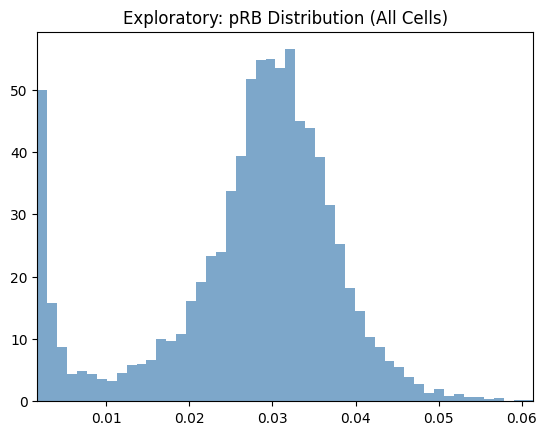

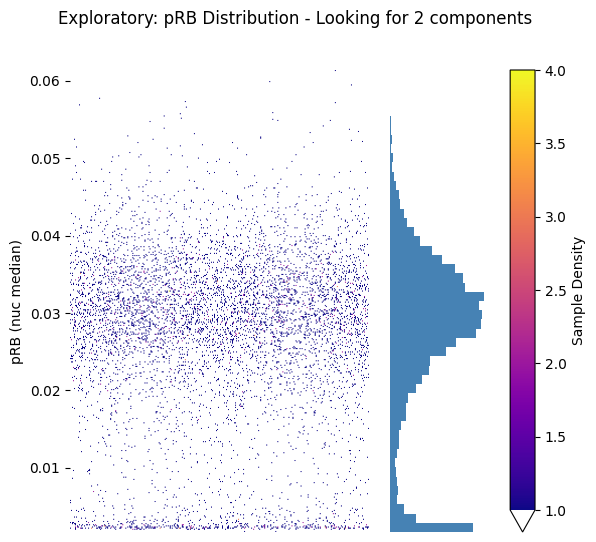

In [53]:
# Explore pRB distribution across all cells
seq_gmm.plot_feature_distribution_exploratory(
    feature='pRB (nuc median)',
    hist_kwargs={'bins': 50, 'color': 'steelblue', 'alpha': 0.7},
)
plt.title('Exploratory: pRB Distribution (All Cells)')
plt.show()

# Or use the strip plot version for better visualization
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='pRB (nuc median)',
    hist_kwargs={'bins': 50, 'color': 'steelblue'},
    scatter_density=True
)
plt.suptitle('Exploratory: pRB Distribution - Looking for 2 components')
plt.show()

In [54]:
# Perform initial thresholding: G0 vs G1/S/G2/M
seq_gmm.threshold_entire_dataset(
    feature='pRB (nuc median)',
    label_obs_save_str='cell_cycle_phase',  # This column will store our labels
    n_components=2,
    ordered_labels=['G0', 'G1/S/G2/M'],
    operation_name='initial_pRB_split'
)

print("Initial thresholding complete!")
print(f"\nLabel distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

Initial thresholding complete!

Label distribution:
cell_cycle_phase
G1/S/G2/M    6101
G0            695
Name: count, dtype: int64


### Visualize Initial Split

Figure saved to: c:\Users\dap182\Documents\git\cc_mapping\notebooks\results\sequential\step1_pRB_split.png


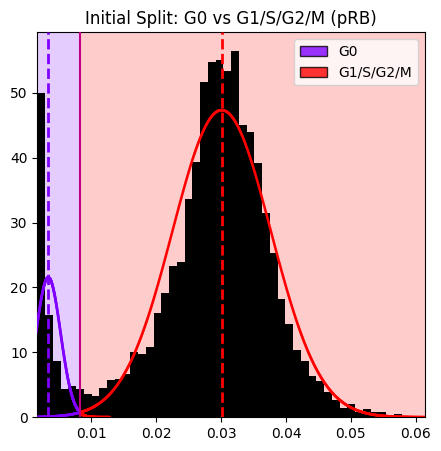

In [55]:
hist_kwargs = {
    'bins': 50, 'color': "black"}

# Plot histogram with decision boundaries
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='initial_pRB_split',
    resolution=1000,
    num_std=5,
    hist_kwargs=hist_kwargs,
    save_path=sequential_results_dir / 'step1_pRB_split.png'  # Optional: save the figure
)
plt.title('Initial Split: G0 vs G1/S/G2/M (pRB)')
plt.show()

**Understanding the Plot:**

The histogram shows the pRB distribution for all cells at the time of this operation, and the GMM fit (curves) and decision boundaries (dashed lines) show where the split between G0 and G1/S/G2/M was calculated.

After subsequent refinement operations, some "G1/S/G2/M" cells get relabeled to "M", "G1", "S", or "G2". When you re-plot this operation later, only cells that **still have** the original labels are shown in the histogram. This is why the plot might look different if viewed after refinements.

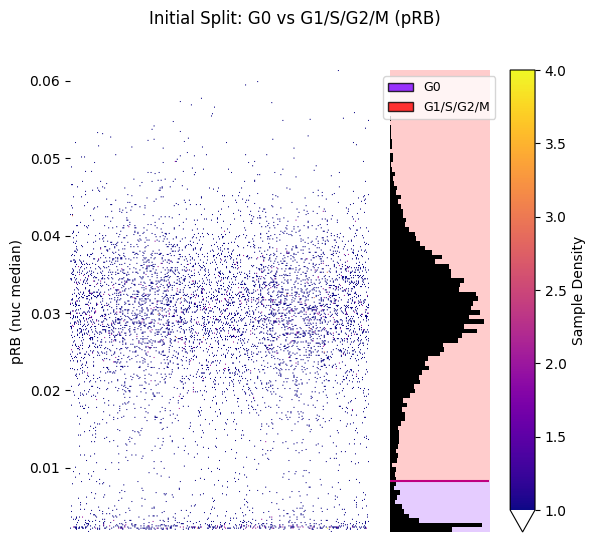

In [56]:
# Strip plot with labels
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='initial_pRB_split',
    hist_kwargs=hist_kwargs,
    scatter_density=True
)
plt.suptitle('Initial Split: G0 vs G1/S/G2/M (pRB)')
plt.show()

<a id="step2"></a>
## 3. Step 2: First Refinement (Separate M Phase)

Now we'll refine the **G1/S/G2/M** population using **p21** to separate M phase cells from the rest.

p21 is typically low in M phase and higher in other phases.

### Exploratory Visualization: M Phase Separation

Before refining, let's explore p21 distribution in the G1/S/G2/M population to see if we can visually identify 2 components.

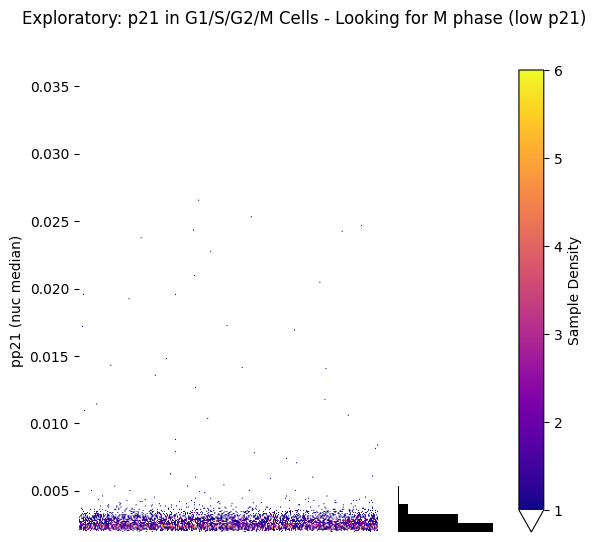

In [57]:
# Explore p21 distribution in G1/S/G2/M cells only (not G0)
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='pp21 (nuc median)',
    obs_label='cell_cycle_phase',
    value_to_subset='G1/S/G2/M',  # Only look at cycling cells
    hist_kwargs={'bins': 50, 'color': 'black'},
    scatter_density=True
)
plt.suptitle('Exploratory: p21 in G1/S/G2/M Cells - Looking for M phase (low p21)')
plt.show()

# This helps us see if 2 components are appropriate and where the boundary might be

In [58]:
# Refine G1/S/G2/M population to separate M phase
seq_gmm.refine_labels_with_gmm(
    feature='pp21 (nuc median)',
    obs_label='cell_cycle_phase',
    value_to_refine='G1/S/G2/M',
    n_components=2,
    ordered_labels=['G1/S/G2','M'],
    operation_name='separate_M_phase',
    duplicate_labels=False
)

print("First refinement complete!")
print(f"\nUpdated label distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

First refinement complete!

Updated label distribution:
cell_cycle_phase
G1/S/G2      6067
G0            695
M              34
G1/S/G2/M       0
Name: count, dtype: int64


### Visualize M Phase Separation

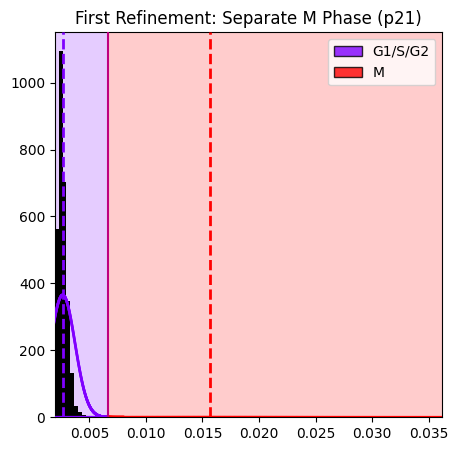

In [59]:
# Plot the M phase separation
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='separate_M_phase',
)
plt.title('First Refinement: Separate M Phase (p21)')
plt.show()

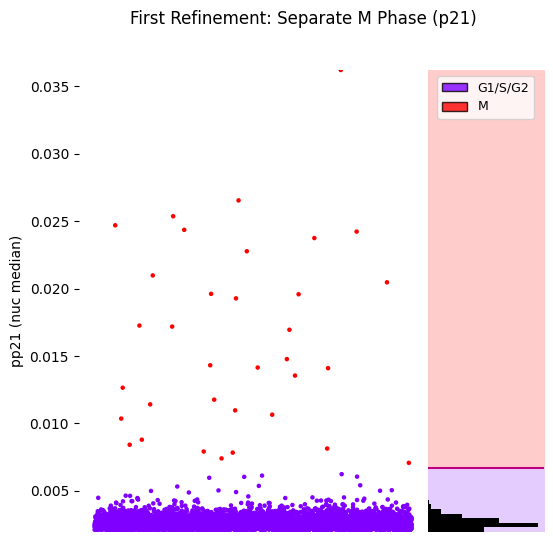

In [60]:
# Strip plot
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='separate_M_phase',
    hist_kwargs=hist_kwargs,
    scatter_density=False,
    title='First Refinement: Separate M Phase (p21)'
)
plt.show()

<a id="step3"></a>
## 4. Step 3: Second Refinement (G1, S, G2)

Finally, we'll refine the **G1/S/G2** population using **DNA content** (Int_Intg_DNA_nuc) to separate the three phases.

DNA content increases through these phases: G1 (2n) → S (2n-4n) → G2 (4n)

### Exploratory Visualization: G1/S/G2 Separation

Before refining, let's explore DNA content distribution in the G1/S/G2 population. This will help us decide whether to use GMM (automatic) or manual thresholds.

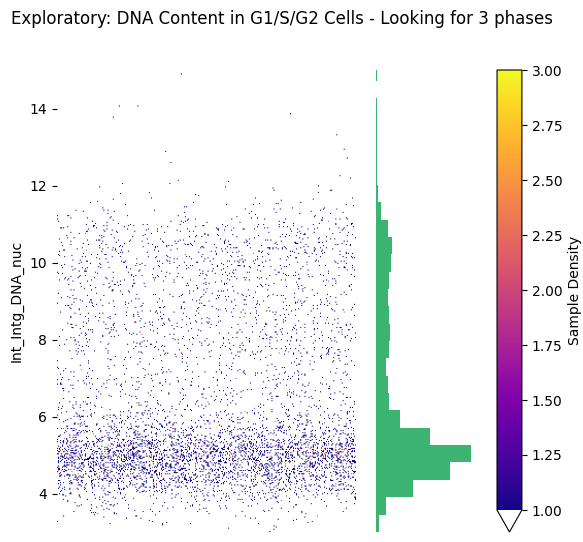

In [61]:
# Explore DNA content distribution in G1/S/G2 cells only
fig, (ax_strip, ax_hist) = seq_gmm.plot_feature_strip_plot_exploratory(
    feature='Int_Intg_DNA_nuc',
    obs_label='cell_cycle_phase',
    value_to_subset='G1/S/G2',  # Only look at G1/S/G2 cells (not M or G0)
    hist_kwargs={'bins': 50, 'color': 'mediumseagreen'},
    scatter_density=True,
    x_axis_limits=(3, 15)
)
plt.suptitle('Exploratory: DNA Content in G1/S/G2 Cells - Looking for 3 phases')
plt.show()

# From this plot, we can:
# - See if 3 components are appropriate
# - Identify potential manual threshold locations (e.g., around 6 and 9)
# - Check for outliers or overlapping distributions

In [62]:
# Refine G1/S/G2 population to separate individual phases
seq_gmm.refine_labels_with_manual_thresholds(
    feature='Int_Intg_DNA_nuc',
    obs_label='cell_cycle_phase',
    value_to_refine='G1/S/G2',
    manual_thresholds=[6, 9],
    ordered_labels=['G1', 'S', 'G2'],
    operation_name='separate_G1_S_G2',
)

print("Second refinement complete!")
print(f"\nFinal label distribution:")
print(seq_gmm.adata.obs['cell_cycle_phase'].value_counts())

Second refinement complete!

Final label distribution:
cell_cycle_phase
G1           3968
S            1151
G2            948
G0            695
M              34
G1/S/G2/M       0
G1/S/G2         0
Name: count, dtype: int64


### Visualize G1/S/G2 Separation

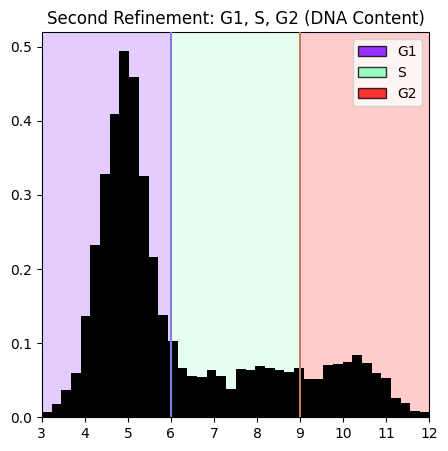

In [63]:
hist_kwargs = {"bins": 100, 'color': 'black'}
# Plot the G1/S/G2 separation
seq_gmm.plot_hist_distribution_with_boundaries(
    operation_name='separate_G1_S_G2',
    hist_kwargs=hist_kwargs,
    x_axis_limits=(3, 12)
)
plt.title('Second Refinement: G1, S, G2 (DNA Content)')
plt.show()

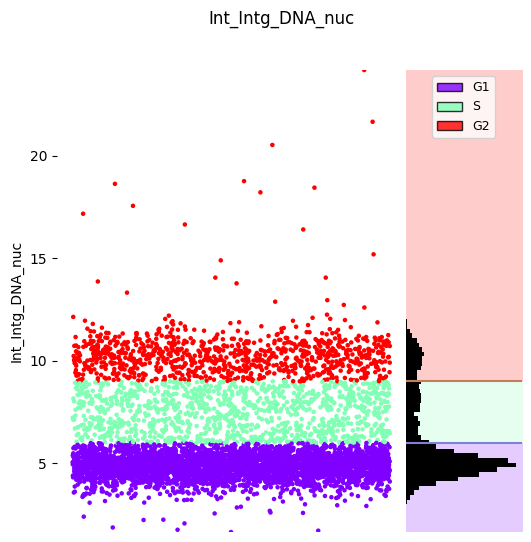

In [64]:
# Strip plot
hist_kwargs = {"bins": 100, 'color': 'black'}
seq_gmm.plot_strip_plot_histogram_with_decision_boundaries(
    operation_name='separate_G1_S_G2',
    hist_kwargs=hist_kwargs,
    scatter_density=False
)
plt.show()

In [65]:
adata_final = seq_gmm.return_adata()

## 6. Utility Functions

The `cc_mapping.thresholding` module provides standalone utility functions for common operations.

### 6.1 Generate Thresholding Report

Generate a summary report of thresholding operations:

In [66]:
from cc_mapping.thresholding import generate_thresholding_report

# Generate a text report
report = generate_thresholding_report(
    adata_final,
    thresholding_events_key='sequential_gmm_thresholding',
    output_format='text'
)
print(report)

Thresholding Report

1. initial_pRB_split (Standard Thresholding)
--------------------------------------------
   Feature: pRB (nuc median)
   Layer: None
   Obs column: cell_cycle_phase
   Components: 2
   Thresholds: [0.0083]
   Labels: ['G0', 'G1/S/G2/M']
   Cell counts: G1/S/G2/M=6101, G0=695

2. separate_M_phase (Refinement) of cell_cycle_phase
----------------------------------------------------
   Feature: pp21 (nuc median)
   Layer: None
   Obs column: cell_cycle_phase
   Components: 2
   Thresholds: [0.0067]
   Labels: ['G1/S/G2', 'M']
   Refined from: ['G1/S/G2/M']
   Cell counts: G1/S/G2=6067, M=34

3. separate_G1_S_G2 (Refinement) of cell_cycle_phase
----------------------------------------------------
   Feature: Int_Intg_DNA_nuc
   Layer: None
   Obs column: cell_cycle_phase
   Components: N/A (manual thresholds)
   Thresholds: [6.0000, 9.0000]
   Labels: ['G1', 'S', 'G2']
   Refined from: ['G1/S/G2']
   Cell counts: G1=3968, S=1151, G2=948

Total operations: 3
Operation 

You can also generate the report as a pandas DataFrame for further analysis:

In [67]:
# Generate a DataFrame report
report_df = generate_thresholding_report(
    adata_final,
    thresholding_events_key='sequential_gmm_thresholding',
    output_format='dataframe'
)
display(report_df)

,Operation,Type,Feature,Layer,Obs Label,Components,Thresholds,Labels,Parent,Refined From,Total Cells
0,1. initial_pRB_split,standard,pRB (nuc median),None,cell_cycle_phase,2,0.0083,"G0, G1/S/G2/M",None,N/A,6796
1,2. separate_M_phase,refinement,pp21 (nuc median),None,cell_cycle_phase,2,0.0067,"G1/S/G2, M",cell_cycle_phase,G1/S/G2/M,6101
2,3. separate_G1_S_G2,refinement_manual,Int_Intg_DNA_nuc,None,cell_cycle_phase,N/A (manual thresholds),"6.0000, 9.0000","G1, S, G2",cell_cycle_phase,G1/S/G2,6067


### 6.2 Boolean Label Combination

Combine categorical labels with boolean operators for advanced filtering. This example shows how to identify cells that are both in a specific treatment group AND in certain cell cycle phases.

The `create_boolean_label_combination()` function supports:
- **AND**: Both conditions must be true
- **OR**: Either condition can be true
- **XOR**: Exactly one condition must be true (not both)

In [69]:
from cc_mapping.thresholding import create_boolean_label_combination
import numpy as np

# Create synthetic treatment labels for demonstration
np.random.seed(42)
n_cells = len(adata_final)
adata_final.obs['treatment'] = pd.Categorical(
    np.random.choice(['Drug_A', 'Drug_B', 'Control'], size=n_cells)
)

# Combine two categorical labels using boolean operators
# operator options: 'AND', 'OR', 'XOR'
adata_final = create_boolean_label_combination(
    adata_final,
    label1='treatment',
    label1_values=['Control'],
    label2='cell_cycle_phase',
    label2_values=['G2', 'M'],  # Combine G2 and M phases
    operator='AND',  # Find cells that are BOTH Control AND in G2 or M phase
    output_label='control_and_G2M',
    positive_label='control_G2M',
    negative_label='other',
    overwrite=False  # Default: raises error if output_label already exists
)

print("Combined label distribution:")
print(adata_final.obs['control_and_G2M'].value_counts())

TypeError: create_boolean_label_combination() got an unexpected keyword argument 'overwrite'